# Calories Burn Prediction: Encoder Decoder Regression

## Importing

In [459]:
# For Encoder part [Data]
import pandas as pd
pd.set_option ("display.float_format", "{:,.2f}".format)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# For decoder part [Models]
## Need Scaling
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

## Don't need Scaling
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Optimization
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# Save the model
import joblib

## Read the data

In [348]:
df = pd.read_excel ('../data/calories_Dataset.xlsx')
print ('Shape:', df.shape)

Shape: (15000, 9)


## We will need these 👇 later

In [349]:
NUM_OF_ROWS = df.shape [0]

to_do = []

def append_to_to_do (task : dict) -> None:
    """
    Used to append what we will to do in the Pipeline After splitting [Avoid data leakage]
    """
    if task not in to_do:
        to_do.append (task)

## Dataset Description from docs

|Feature| Type |
|---|---|
|User_ID| Categorical| 
|Gender| Categorical| 
|Age| Numerical| 
|Height| Numerical| 
|Weight| Numerical| 
|Duration| Numerical| 
|Heart_Rate| Numerical| 
|Body_Temp| Numerical|

<br>

|Target |Type| 
|---|---|
|Calories| Numerical |

## 1. Data Understanding

In [350]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      14100 non-null  object 
 2   Age         15000 non-null  float64
 3   Height      15000 non-null  float64
 4   Weight      13800 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  14340 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  int64  
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


## 2. Drop useless columns

In [351]:
df = df.drop (columns= ['User_ID'])
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
       'Body_Temp', 'Calories'],
      dtype='object')

In [352]:
task = {
    'action': 'Drop useless columns',
    'columns': 'User_ID'
}

append_to_to_do (task)

In [353]:
cat_cols = df.select_dtypes (include= 'object').columns.tolist ()

num_cols = df.select_dtypes (include= 'number').columns.tolist ()

print ("Numeral columns:", num_cols)
print ("Categorical columns:", cat_cols)

Numeral columns: ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']
Categorical columns: ['Gender']


In [354]:
# Categorical columns ["Gender"]
print ('No.of unique values:', len (df ['Gender'].unique ()))
print ('Unique Values:', df ['Gender'].unique ().tolist ())

No.of unique values: 3
Unique Values: ['male', 'female', nan]


In [355]:
# Numeral columns
df [num_cols].describe ()

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,"15,000.00","15,000.00","13,800.00","15,000.00","14,340.00","15,000.00","15,000.00"
mean,44.52,181.61,78.04,16.11,99.43,41.62,89.54
std,22.33,53.85,27.33,9.83,29.93,11.65,62.46
min,20.00,123.00,36.00,1.00,67.00,37.10,1.00
25%,28.00,164.00,63.00,8.00,89.00,39.60,35.00
50%,40.00,175.00,75.00,16.00,96.00,40.20,79.00
75%,57.00,186.00,87.00,23.00,103.00,40.60,138.00
max,306.17,802.14,438.03,111.61,447.64,163.44,314.00


## 3. Check and remove Duplicates

In [356]:
print (df.duplicated ().sum ())
df.drop_duplicates (inplace= True)
df.duplicated ().sum ()

1


np.int64(0)

In [357]:
task = {
    'action': 'drop duplicates',
    'columns': 'all'
}

append_to_to_do (task)

to_do

[{'action': 'Drop useless columns', 'columns': 'User_ID'},
 {'action': 'drop duplicates', 'columns': 'all'}]

## 4. Data Visualization 

### Numerical features

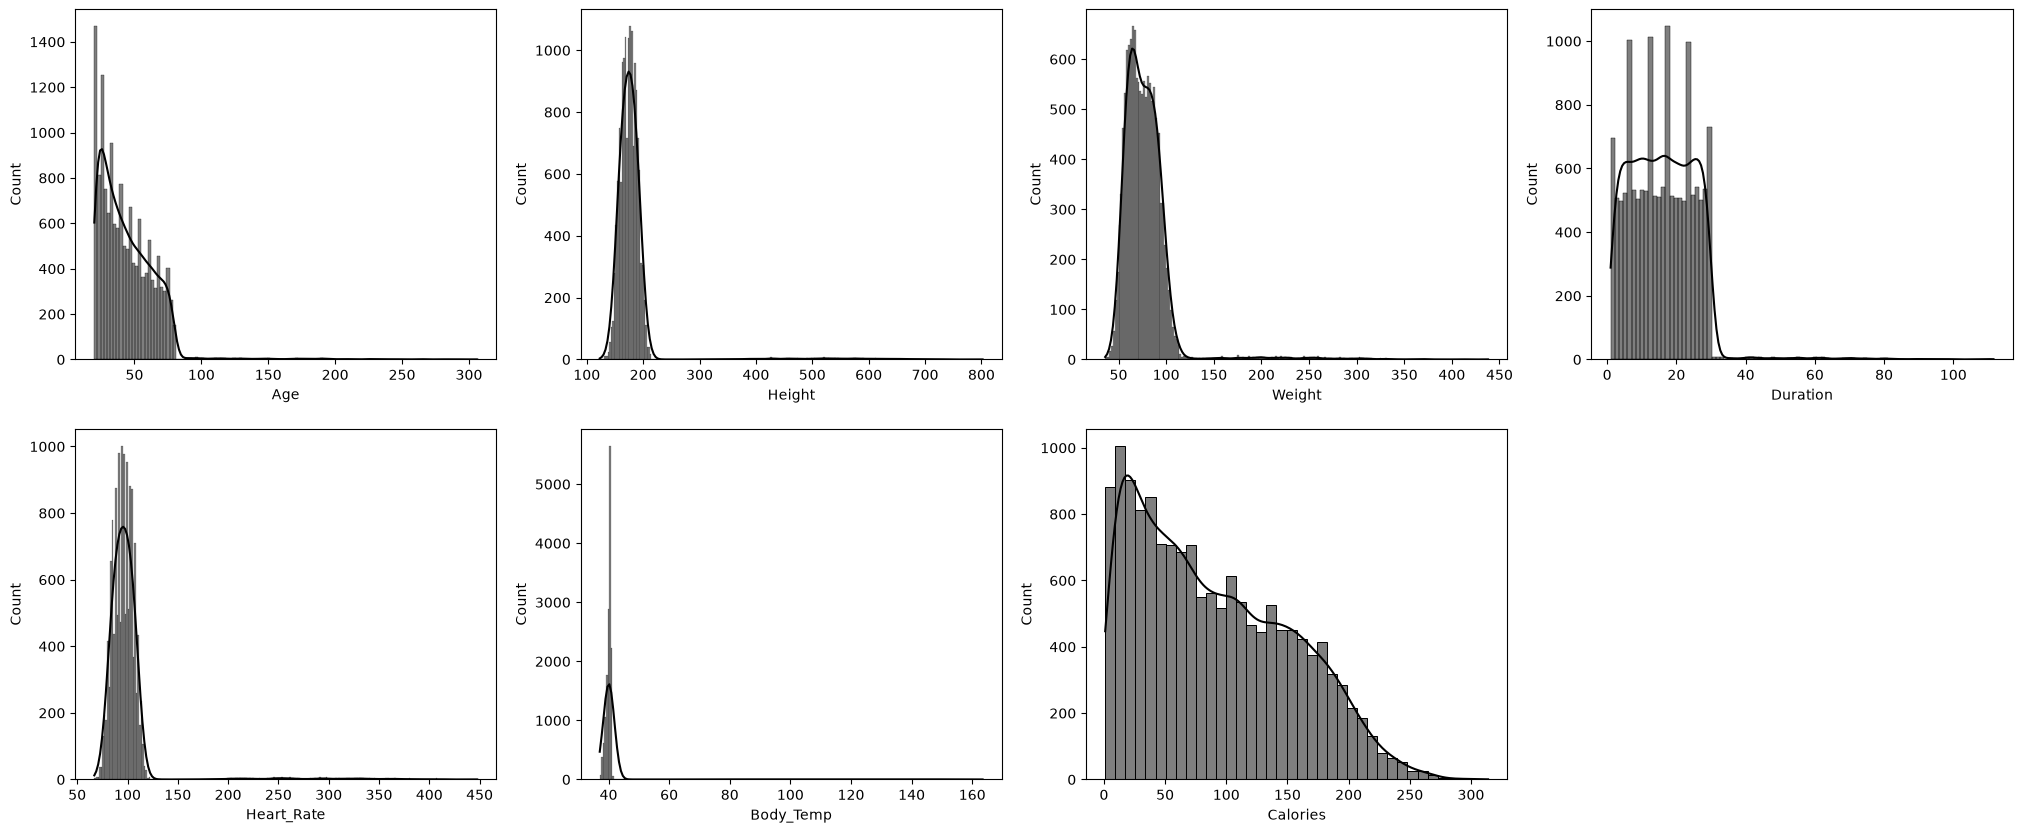

In [358]:
plt.figure (figsize= (25, 10))
for i, col in enumerate (num_cols, start= 1):
    plt.subplot (2, 4, i)
    sns.histplot (data= df, x= col, kde= True, color= "black")

plt.show ()

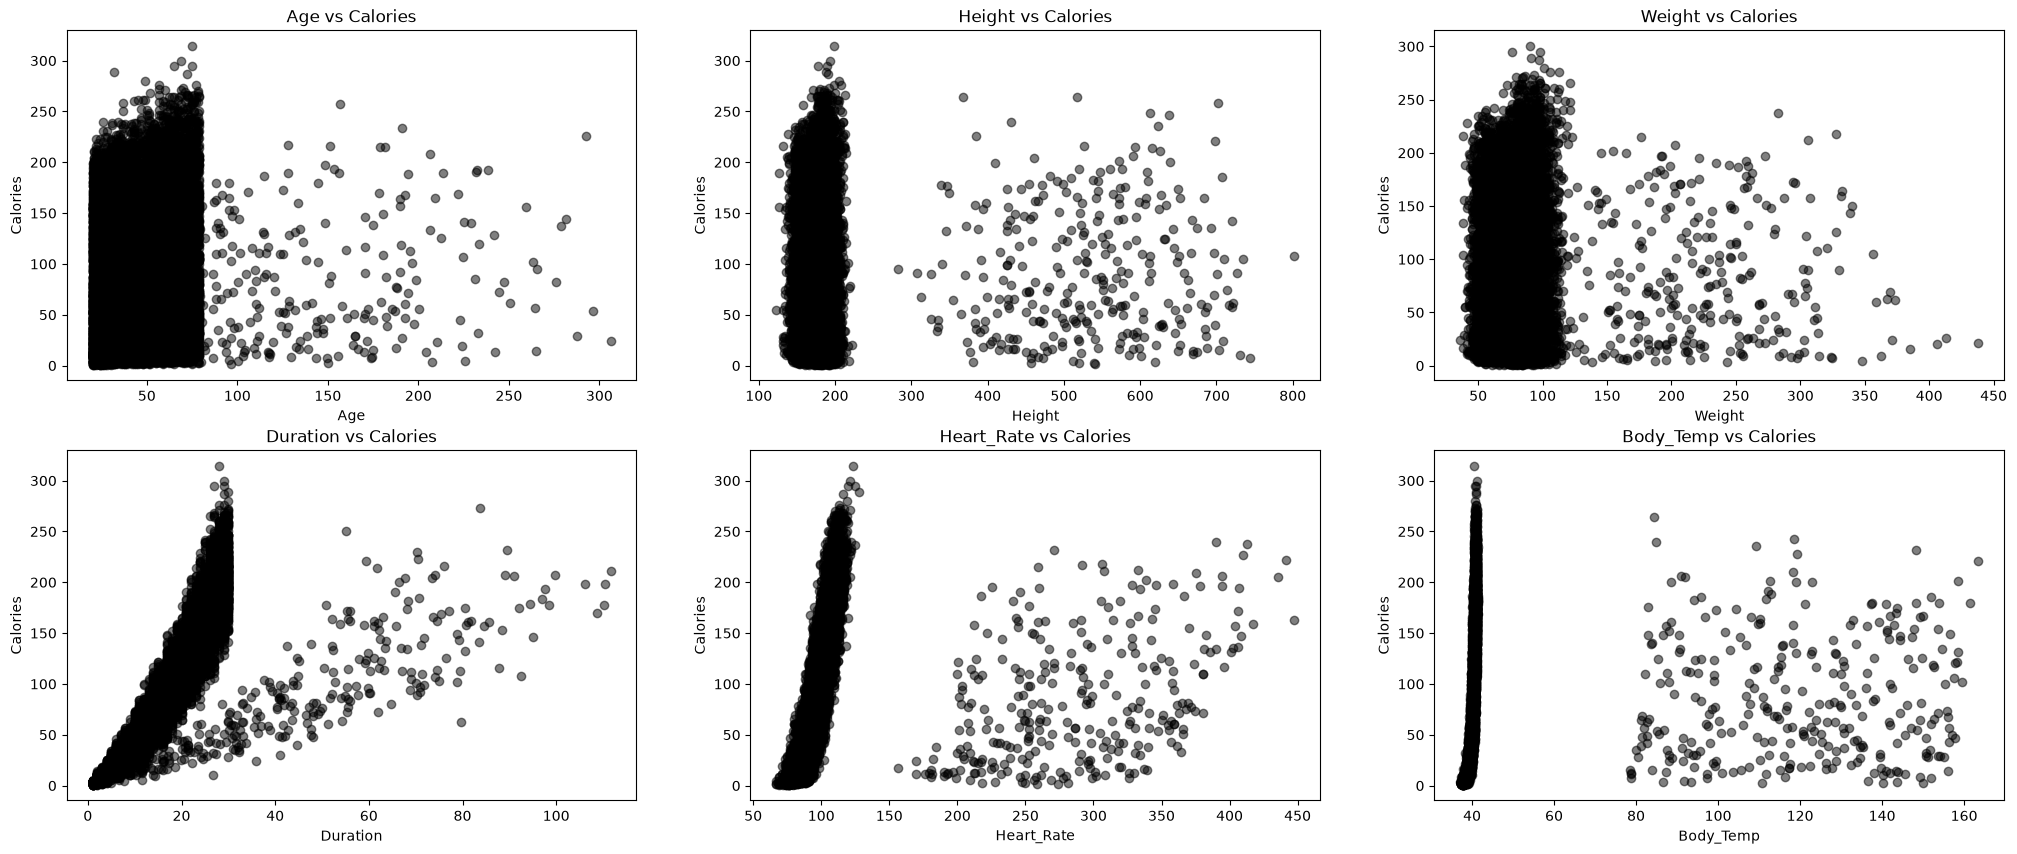

In [359]:
plt.figure (figsize= (25, 10))

if 'Calories' in num_cols:
    num_cols.remove ('Calories')

for i, col in enumerate (num_cols , start= 1):
    plt.subplot (2, 3, i)
    plt.scatter (df [col], df ["Calories"], color= "black", alpha= 0.5)
    plt.title (f"{col} vs Calories")
    plt.xlabel (col)
    plt.ylabel ("Calories")

plt.show ()

if 'Calories' not in num_cols:
    num_cols.append ('Calories')

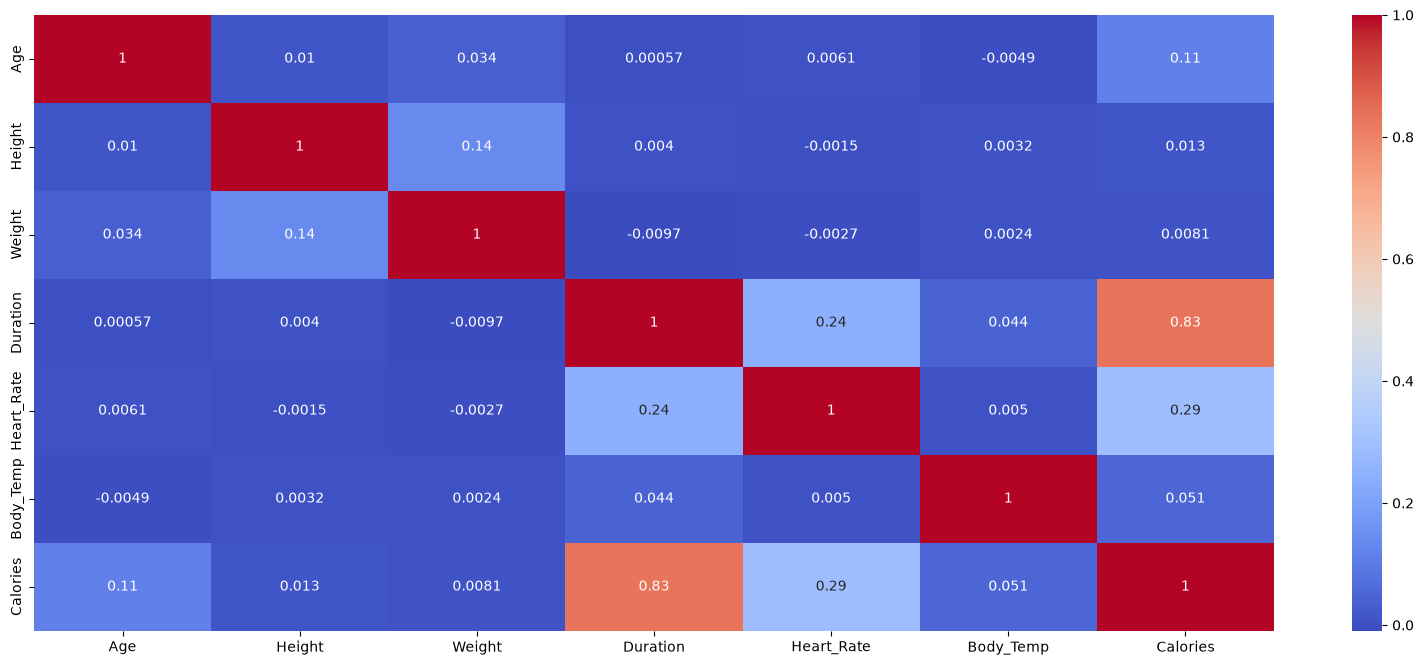

In [360]:
plt.figure (figsize= (20, 8))

corr = df.corr (numeric_only= True)
sns.heatmap (corr, annot= True, cmap= "coolwarm")
plt.show ()

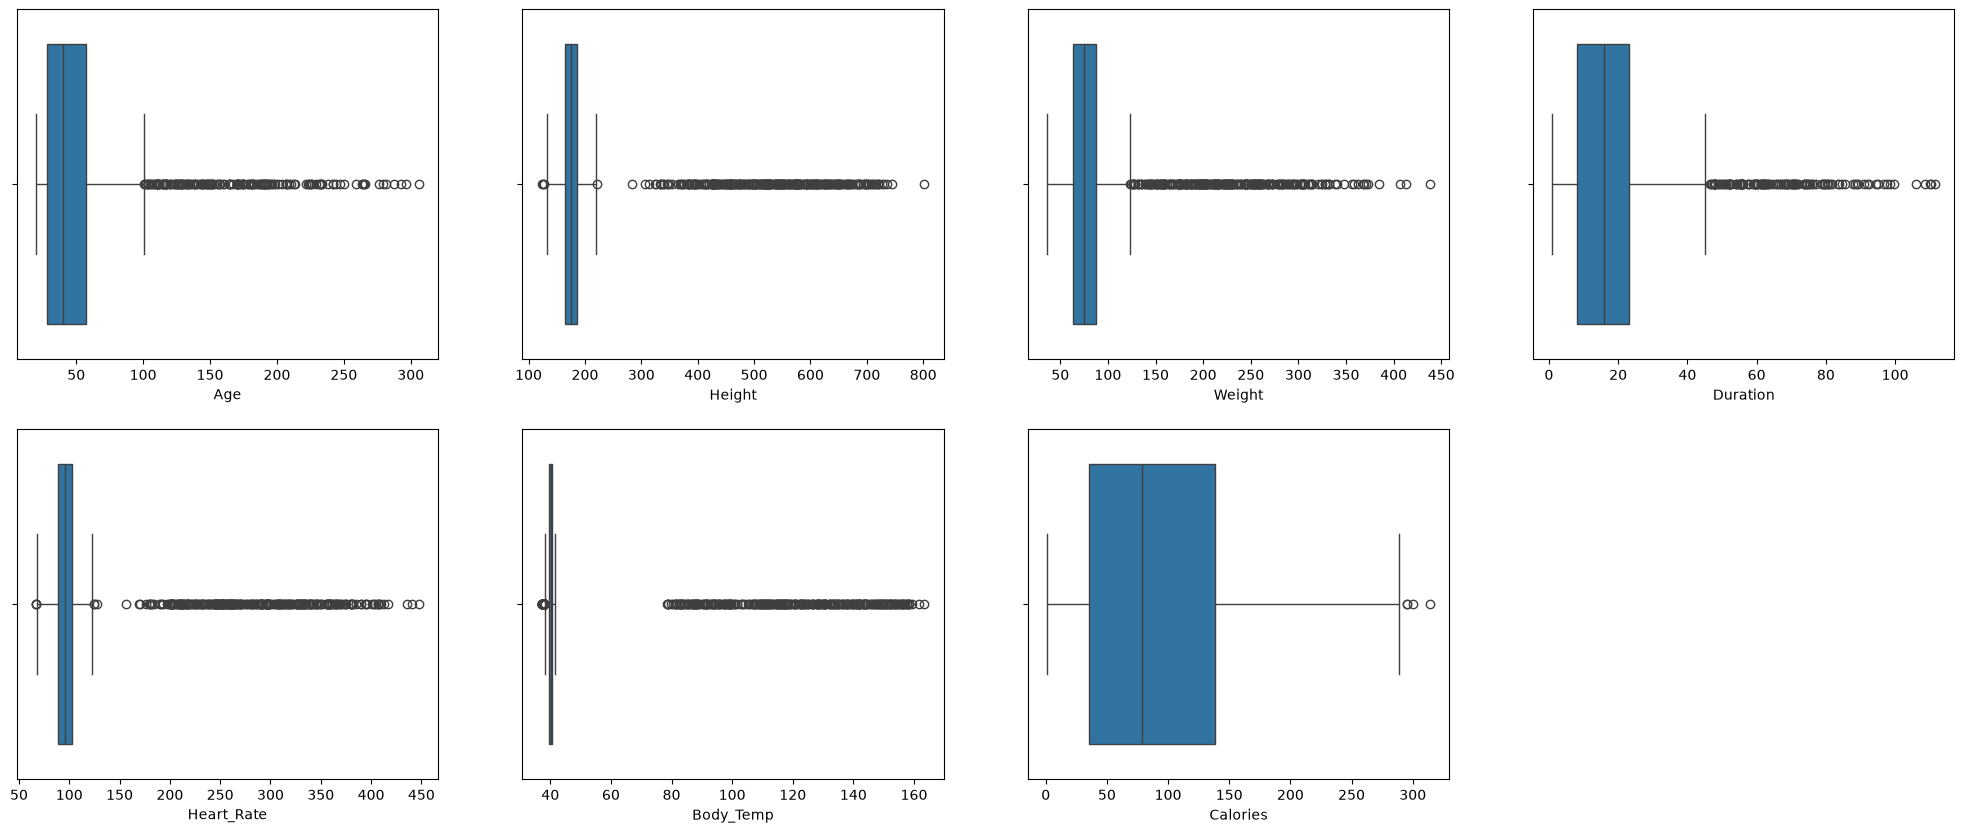

In [361]:
plt.figure (figsize= (25, 10))

for i, col in enumerate (num_cols, start= 1):
    plt.subplot (2, 4, i)
    sns.boxplot (data= df, x= col)

plt.show ()

### Categorical features

In [362]:
cat_cols

['Gender']

In [363]:
gender_counts = df ['Gender'].value_counts ()
gender_counts

Gender
female    7096
male      7003
Name: count, dtype: int64

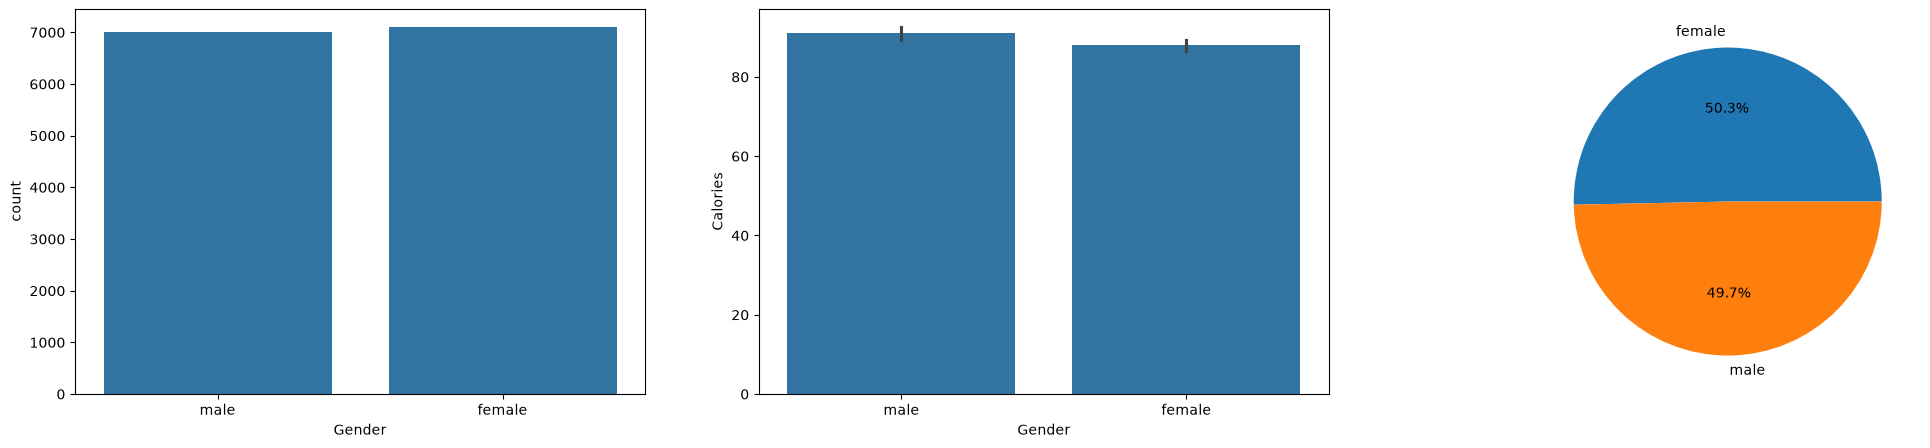

In [364]:
plt.figure (figsize= (25, 5))

plt.subplot (1, 3, 1)
sns.countplot (data= df, x= 'Gender')

plt.subplot (1, 3, 2)
sns.barplot (data= df, x= 'Gender', y= 'Calories')

plt.subplot (1, 3, 3)
plt.pie (gender_counts, labels= gender_counts.index, autopct= '%1.1f%%')

plt.show ()

## 5. Check & Handle Data Quality Issues like:- invalid, missing

In [365]:
df.describe ()

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,"14,999.00","14,999.00","13,799.00","14,999.00","14,339.00","14,999.00","14,999.00"
mean,44.52,181.61,78.04,16.11,99.43,41.62,89.54
std,22.33,53.86,27.34,9.83,29.93,11.65,62.46
min,20.00,123.00,36.00,1.00,67.00,37.10,1.00
25%,28.00,164.00,63.00,8.00,89.00,39.60,35.00
50%,40.00,175.00,75.00,16.00,96.00,40.20,79.00
75%,57.00,186.00,87.00,23.00,103.00,40.60,138.00
max,306.17,802.14,438.03,111.61,447.64,163.44,314.00


### missing values

In [366]:
nan_cols = df.isna ().sum ()
percentage = (nan_cols / len (df) * 100).round (2)

missing = pd.DataFrame ({
    "missing": nan_cols,
    "percentage": percentage
})

missing = missing [missing ["missing"] > 0]
missing = missing.sort_values ("missing", ascending= False)

missing

,missing,percentage
Weight,1200,8.00
Gender,900,6.00
Heart_Rate,660,4.40


#### missing values in Categorical column: `Gender`

In [367]:
df ['Gender'].value_counts ()

Gender
female    7096
male      7003
Name: count, dtype: int64

In [368]:
mode = df ['Gender'].mode () [0]
df ['Gender'] = df ['Gender'].fillna (value= mode)

In [369]:
task = {
    'action' : 'Fill with mode',
    'columns' : 'Gender'
}

append_to_to_do (task)
to_do

[{'action': 'Drop useless columns', 'columns': 'User_ID'},
 {'action': 'drop duplicates', 'columns': 'all'},
 {'action': 'Fill with mode', 'columns': 'Gender'}]

#### missing values in Numerical column

In [370]:
nan_cols = df.isna ().sum ()
percentage = (nan_cols / len (df) * 100).round (2)

missing = pd.DataFrame ({
    "missing": nan_cols,
    "percentage": percentage
})

missing = missing [missing ["missing"] > 0]
missing = missing.sort_values ("missing", ascending= False)

missing

,missing,percentage
Weight,1200,8.00
Heart_Rate,660,4.40


In [371]:
nan_num_cols = ['Weight', 'Heart_Rate']
nan_num_cols

['Weight', 'Heart_Rate']

In [372]:
df [nan_num_cols].describe ()

,Weight,Heart_Rate
count,"13,799.00","14,339.00"
mean,78.04,99.43
std,27.34,29.93
min,36.00,67.00
25%,63.00,89.00
50%,75.00,96.00
75%,87.00,103.00
max,438.03,447.64


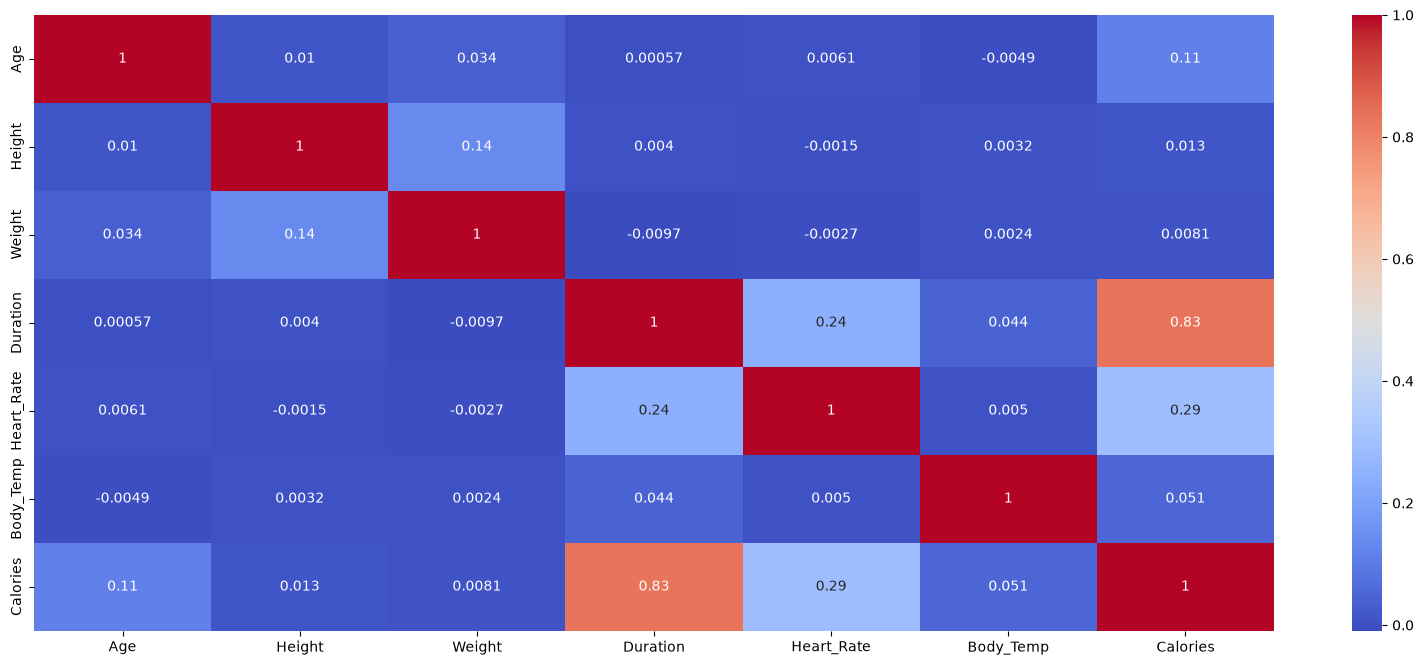

In [373]:
plt.figure (figsize= (20, 8))

corr = df.corr (numeric_only= True)
sns.heatmap (corr, annot= True, cmap= "coolwarm")
plt.show ()

In [374]:
for col in nan_num_cols:
    print ('Column Name:', col)
    mean = df [col].mean ()
    median = df [col].median ()
    print ('Mean:', mean)
    print ('Median:', median)
    print ('Mean - Median =', abs (mean - median))
    print ('-' * 20, '\n')

Column Name: Weight
Mean: 78.04342892841098
Median: 75.0
Mean - Median = 3.0434289284109752
-------------------- 

Column Name: Heart_Rate
Mean: 99.4340437785779
Median: 96.0
Mean - Median = 3.4340437785779017
-------------------- 



In [375]:
for col in nan_num_cols:
    median = df [col].median ()
    df [col] = df [col].fillna (value= median)

In [376]:
df.isna ().sum ()

Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [377]:
task = {
    'action' : 'fill with median',
    'columns' : '[Weight, Heart_Rate]'
}

append_to_to_do (task)
to_do

[{'action': 'Drop useless columns', 'columns': 'User_ID'},
 {'action': 'drop duplicates', 'columns': 'all'},
 {'action': 'Fill with mode', 'columns': 'Gender'},
 {'action': 'fill with median', 'columns': '[Weight, Heart_Rate]'}]

### Search if we have invalid values

In [378]:
df.describe ()

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,"14,999.00","14,999.00","14,999.00","14,999.00","14,999.00","14,999.00","14,999.00"
mean,44.52,181.61,77.80,16.11,99.28,41.62,89.54
std,22.33,53.86,26.23,9.83,29.27,11.65,62.46
min,20.00,123.00,36.00,1.00,67.00,37.10,1.00
25%,28.00,164.00,64.00,8.00,89.00,39.60,35.00
50%,40.00,175.00,75.00,16.00,96.00,40.20,79.00
75%,57.00,186.00,86.00,23.00,103.00,40.60,138.00
max,306.17,802.14,438.03,111.61,447.64,163.44,314.00


In [379]:
df [df ['Age'] > 100]['Age'].value_counts ().sort_index (ascending= False).sample (20)

Age
109.41    1
117.41    1
159.88    1
224.57    1
104.88    1
187.69    1
110.09    1
150.51    1
182.10    1
148.63    1
279.03    1
175.03    1
244.45    1
115.66    1
112.21    1
242.24    1
178.01    1
151.32    1
156.48    1
170.16    1
Name: count, dtype: int64

In [380]:
df [df ['Height'] > 200]['Height'].value_counts ().sort_index (ascending= False).sample (20)

Height
396.16    1
376.56    1
553.77    1
573.27    1
373.53    1
594.33    1
519.15    1
618.94    1
536.42    1
412.16    1
415.09    1
674.25    1
450.78    1
503.23    1
668.13    1
576.33    1
335.30    1
674.38    1
495.24    1
744.59    1
Name: count, dtype: int64

In [381]:
df [df ['Weight'] > 100]['Weight'].value_counts ().sort_index (ascending= False).sample (20)

Weight
205.07    1
257.99    1
187.14    1
267.88    1
302.96    1
254.96    1
196.30    1
236.73    1
328.03    1
187.69    1
290.17    1
252.54    1
295.61    1
347.50    1
283.38    1
221.51    1
214.83    1
258.33    1
123.39    1
245.00    1
Name: count, dtype: int64

In [382]:
df [df ['Weight'] > 150]['Weight'].value_counts ().sort_index (ascending= False).sample (20)

Weight
221.44    1
165.42    1
331.84    1
200.12    1
369.24    1
258.12    1
294.24    1
162.12    1
180.31    1
245.17    1
314.78    1
215.17    1
209.51    1
243.80    1
229.84    1
196.62    1
158.82    1
159.33    1
286.43    1
277.14    1
Name: count, dtype: int64

In [383]:
df.describe ()

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,"14,999.00","14,999.00","14,999.00","14,999.00","14,999.00","14,999.00","14,999.00"
mean,44.52,181.61,77.80,16.11,99.28,41.62,89.54
std,22.33,53.86,26.23,9.83,29.27,11.65,62.46
min,20.00,123.00,36.00,1.00,67.00,37.10,1.00
25%,28.00,164.00,64.00,8.00,89.00,39.60,35.00
50%,40.00,175.00,75.00,16.00,96.00,40.20,79.00
75%,57.00,186.00,86.00,23.00,103.00,40.60,138.00
max,306.17,802.14,438.03,111.61,447.64,163.44,314.00


In [384]:
df [df ['Heart_Rate'] > 100]['Heart_Rate'].value_counts ().sort_index (ascending= False).sample (20)

Heart_Rate
330.55    1
257.17    1
222.00    1
249.88    1
212.51    1
227.50    1
296.28    1
358.56    1
349.59    1
271.03    1
338.09    1
212.06    1
332.73    1
232.45    1
297.78    1
307.32    1
258.44    1
322.04    1
231.09    1
207.58    1
Name: count, dtype: int64

`Not invalid but maybe outliers`

## 6. Analyze Target

In [385]:
df ['Calories'].describe ()

count   14,999.00
mean        89.54
std         62.46
min          1.00
25%         35.00
50%         79.00
75%        138.00
max        314.00
Name: Calories, dtype: float64

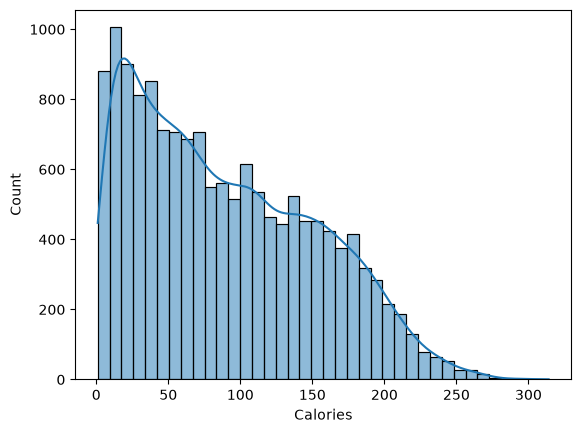

In [386]:
sns.histplot (data= df, x= "Calories", kde= True)
plt.show ()

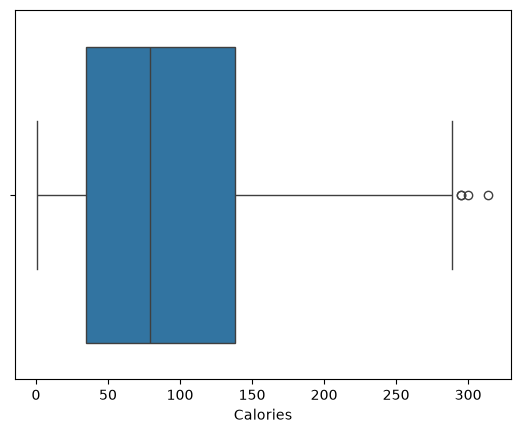

In [387]:
sns.boxplot (data= df, x= "Calories")
plt.show ()

In [388]:
Q1 = df ["Calories"].quantile (0.25)
Q3 = df ["Calories"].quantile (0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print ("Lower Bound:", lower_bound)
print ("Upper Bound:", upper_bound)

print ("Potential Outliers:")
print (df [df ["Calories"] > upper_bound]["Calories"].count ())

Lower Bound: -119.5
Upper Bound: 292.5
Potential Outliers:
4


In [389]:
df [df ["Calories"] > 292.5]

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
428,male,75.00,199.00,75.00,28.00,123.00,40.50,314
3357,male,65.00,189.00,98.00,27.00,125.00,40.90,295
6240,male,69.00,193.00,90.00,29.00,121.00,41.10,300
13871,male,75.00,178.00,76.00,29.00,120.00,40.80,295


<p style= "color: #88E788;"> Keep ✅ </p>

## 7. Detect & Handle Outliers

In [390]:
def calc_lower_upper_bound (
        df : pd.DataFrame, col : str,
        lower_bound : float = None, upper_bound : float = None
        ):

    Q1 = df [col].quantile (0.25)
    Q3 = df [col].quantile (0.75)

    IQR = Q3 - Q1

    if lower_bound is None:
        lower_bound = Q1 - 1.5 * IQR

    if upper_bound is None:
        upper_bound = Q3 + 1.5 * IQR

    return lower_bound, upper_bound

In [391]:
print (len (num_cols))
num_cols

7


['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']

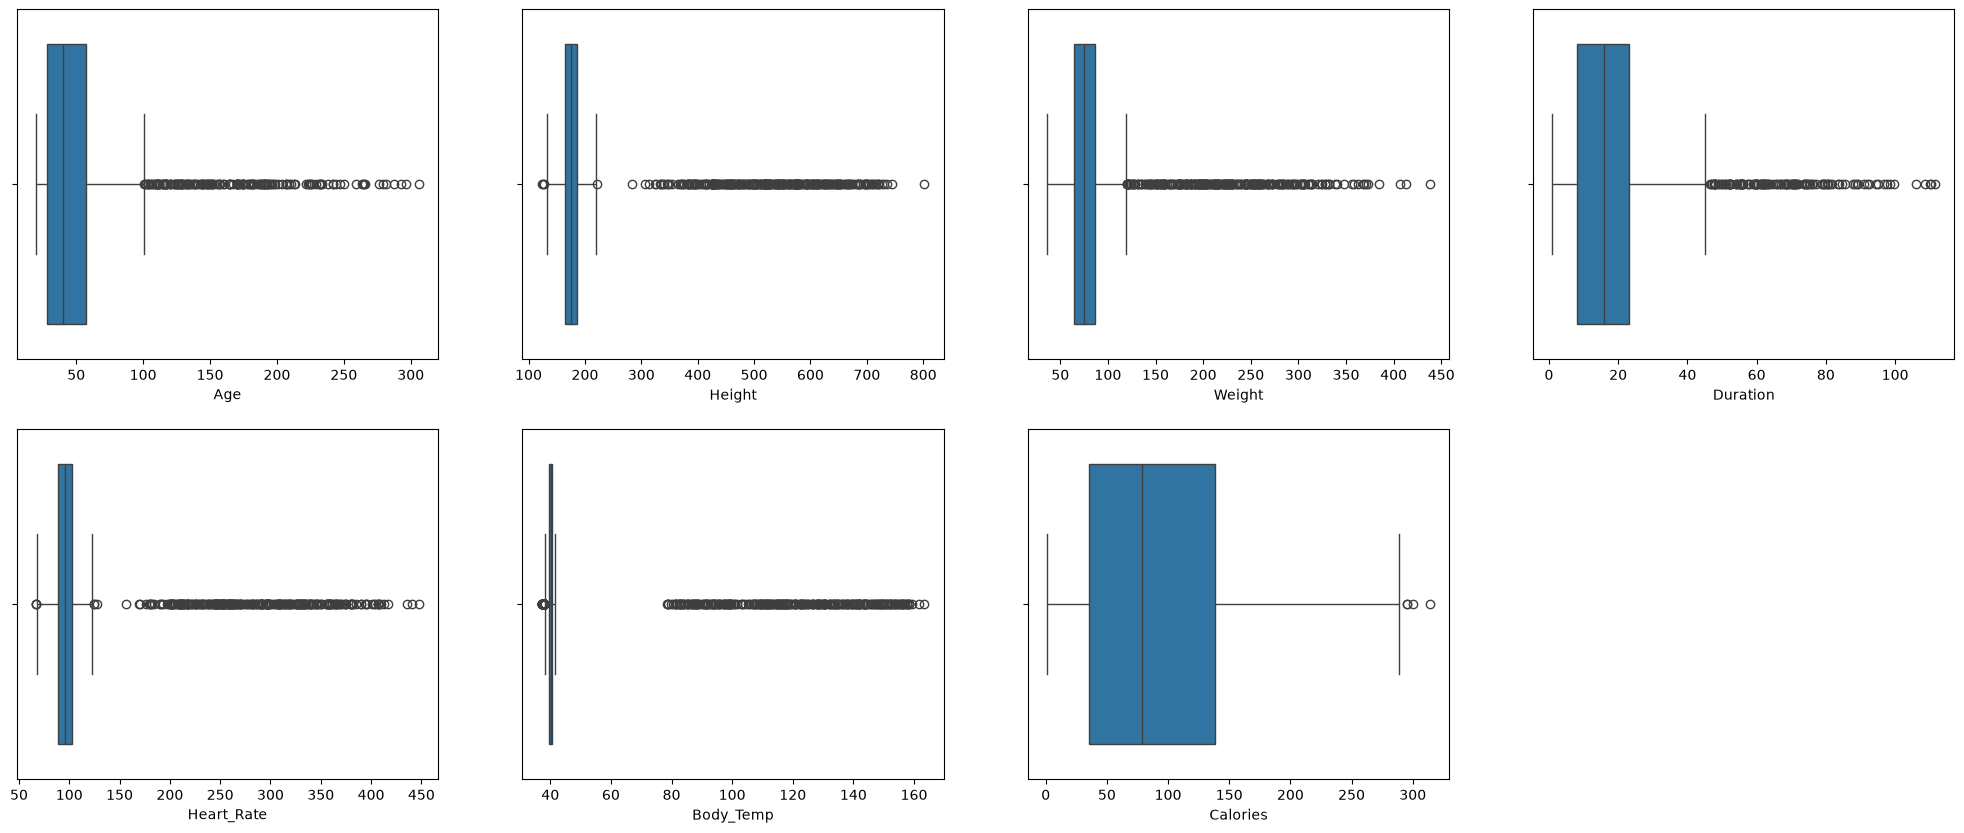

In [392]:
plt.figure (figsize= (25, 10))

for i, col in enumerate (num_cols, start= 1):
    plt.subplot (2, 4, i)
    sns.boxplot (data= df, x= col)

plt.show ()

In [393]:
for col in num_cols:
    print ('Col name:', col)

    if col in ('Age', 'Duration', 'Calories'):
        lower_bound, upper_bound = calc_lower_upper_bound (df, col, 0)
    else:
        lower_bound, upper_bound = calc_lower_upper_bound (df, col)

    print ('Lower bound:', lower_bound)
    print ('Upper bound:', upper_bound)

    # condition = (df [col] > lower_bound) & (df [col] < upper_bound)
    condition = df [col].between (lower_bound, upper_bound)
    print (len (df) - len (df [condition]))

    print ('-' * 20, '\n')

Col name: Age
Lower bound: 0
Upper bound: 100.5
173
-------------------- 

Col name: Height
Lower bound: 131.0
Upper bound: 219.0
304
-------------------- 

Col name: Weight
Lower bound: 31.0
Upper bound: 119.0
284
-------------------- 

Col name: Duration
Lower bound: 0
Upper bound: 45.5
132
-------------------- 

Col name: Heart_Rate
Lower bound: 68.0
Upper bound: 124.0
298
-------------------- 

Col name: Body_Temp
Lower bound: 38.1
Upper bound: 42.1
661
-------------------- 

Col name: Calories
Lower bound: 0
Upper bound: 292.5
4
-------------------- 



### Calories

In [394]:
df.loc [
    ~df ['Calories'].between (0, 292.5),
    ['Age', 'Height', 'Weight', 'Duration',
     'Heart_Rate', 'Body_Temp', 'Calories']
]

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
428,75.00,199.00,75.00,28.00,123.00,40.50,314
3357,65.00,189.00,98.00,27.00,125.00,40.90,295
6240,69.00,193.00,90.00,29.00,121.00,41.10,300
13871,75.00,178.00,76.00,29.00,120.00,40.80,295


<p style= "color: #88E788;"> Keep ✅ </p>

### Age

In [395]:
df ['Age'].describe ()

count   14,999.00
mean        44.52
std         22.33
min         20.00
25%         28.00
50%         40.00
75%         57.00
max        306.17
Name: Age, dtype: float64

In [396]:
AGE_MAX = 100

In [397]:
df = df [df ['Age'] <= AGE_MAX]

In [398]:
df ['Age'].describe ()

count   14,823.00
mean        43.06
std         17.19
min         20.00
25%         28.00
50%         40.00
75%         56.00
max         98.23
Name: Age, dtype: float64

In [399]:
task = {
    'action' : f'Remove the ages that greater than {AGE_MAX}',
    'columns' : 'Age'
}

append_to_to_do (task)
to_do

[{'action': 'Drop useless columns', 'columns': 'User_ID'},
 {'action': 'drop duplicates', 'columns': 'all'},
 {'action': 'Fill with mode', 'columns': 'Gender'},
 {'action': 'fill with median', 'columns': '[Weight, Heart_Rate]'},
 {'action': 'Remove the ages that greater than 100', 'columns': 'Age'}]

### Height

In [400]:
df ['Height'].describe ()

count   14,823.00
mean       181.55
std         53.68
min        123.00
25%        164.00
50%        175.00
75%        186.00
max        802.14
Name: Height, dtype: float64

In [401]:
HEIGHT_MAX = 219 # Upper bound

In [402]:
df = df [df ["Height"] <= HEIGHT_MAX]

In [403]:
df ['Height'].describe ()

count   14,528.00
mean       174.48
std         14.25
min        123.00
25%        164.00
50%        175.00
75%        185.00
max        219.00
Name: Height, dtype: float64

In [404]:
task = {
    'action' : f'Remove the Height that greater than {HEIGHT_MAX}',
    'columns' : 'Height'
}

append_to_to_do (task)
to_do

[{'action': 'Drop useless columns', 'columns': 'User_ID'},
 {'action': 'drop duplicates', 'columns': 'all'},
 {'action': 'Fill with mode', 'columns': 'Gender'},
 {'action': 'fill with median', 'columns': '[Weight, Heart_Rate]'},
 {'action': 'Remove the ages that greater than 100', 'columns': 'Age'},
 {'action': 'Remove the Height that greater than 219', 'columns': 'Height'}]

### Weight

In [405]:
df ['Weight'].describe ()

count   14,528.00
mean        77.81
std         26.24
min         36.00
25%         64.00
50%         75.00
75%         86.00
max        438.03
Name: Weight, dtype: float64

In [406]:
WEIGHT_MAX = 119 # Upper bound

In [407]:
df = df [df ["Weight"] <= WEIGHT_MAX]

In [408]:
df ['Weight'].describe ()

count   14,256.00
mean        75.01
std         14.34
min         36.00
25%         64.00
50%         75.00
75%         85.00
max        119.00
Name: Weight, dtype: float64

In [409]:
task = {
    'action' : f'Remove the Weight that greater than {WEIGHT_MAX}',
    'columns' : 'Weight'
}

append_to_to_do (task)
to_do

[{'action': 'Drop useless columns', 'columns': 'User_ID'},
 {'action': 'drop duplicates', 'columns': 'all'},
 {'action': 'Fill with mode', 'columns': 'Gender'},
 {'action': 'fill with median', 'columns': '[Weight, Heart_Rate]'},
 {'action': 'Remove the ages that greater than 100', 'columns': 'Age'},
 {'action': 'Remove the Height that greater than 219', 'columns': 'Height'},
 {'action': 'Remove the Weight that greater than 119', 'columns': 'Weight'}]

### Duration

In [410]:
df ['Duration'].describe ()

count   14,256.00
mean        16.13
std          9.83
min          1.00
25%          8.49
50%         16.00
75%         23.00
max        111.61
Name: Duration, dtype: float64

<p style= "color: #88E788;"> Keep ✅ </p>

### Heart_Rate

In [411]:
df ['Heart_Rate'].describe ()

count   14,256.00
mean        99.37
std         29.52
min         67.00
25%         89.00
50%         96.00
75%        103.00
max        447.64
Name: Heart_Rate, dtype: float64

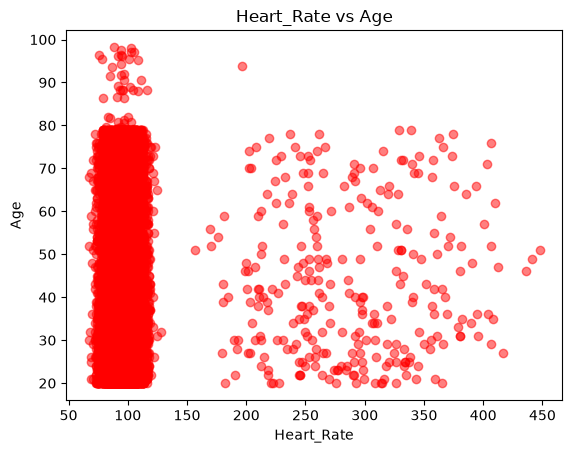

In [412]:
plt.scatter (df ["Heart_Rate"], df ["Age"], color= "red", alpha= 0.5)
plt.title ("Heart_Rate vs Age")
plt.xlabel ("Heart_Rate")
plt.ylabel ("Age")
plt.show ()

#### Use domain knowledge to remove physiologically implausible values.

In [413]:
HEART_RATE_MAX = 124

In [414]:
df = df [df ["Heart_Rate"] <= HEART_RATE_MAX]

In [415]:
df ['Heart_Rate'].describe ()

count   13,971.00
mean        95.58
std          9.35
min         67.00
25%         89.00
50%         96.00
75%        102.00
max        123.00
Name: Heart_Rate, dtype: float64

In [416]:
task = {
    'action' : f'remove the Heart_Rate that greater than {HEART_RATE_MAX}',
    'columns' : 'Heart_Rate'
}

append_to_to_do (task)
to_do

[{'action': 'Drop useless columns', 'columns': 'User_ID'},
 {'action': 'drop duplicates', 'columns': 'all'},
 {'action': 'Fill with mode', 'columns': 'Gender'},
 {'action': 'fill with median', 'columns': '[Weight, Heart_Rate]'},
 {'action': 'Remove the ages that greater than 100', 'columns': 'Age'},
 {'action': 'Remove the Height that greater than 219', 'columns': 'Height'},
 {'action': 'Remove the Weight that greater than 119', 'columns': 'Weight'},
 {'action': 'remove the Heart_Rate that greater than 124',
  'columns': 'Heart_Rate'}]

### Body_Temp

In [417]:
df ['Body_Temp'].describe ()

count   13,971.00
mean        41.62
std         11.66
min         37.10
25%         39.60
50%         40.20
75%         40.60
max        163.44
Name: Body_Temp, dtype: float64

In [418]:
BODY_TEMP_MAX = 43

In [419]:
df = df[df["Body_Temp"] <= BODY_TEMP_MAX]

In [420]:
df ['Body_Temp'].describe ()

count   13,693.00
mean        40.03
std          0.78
min         37.10
25%         39.60
50%         40.20
75%         40.60
max         41.50
Name: Body_Temp, dtype: float64

In [421]:
task = {
    'action' : f'remove the Body_Temp that greater than {BODY_TEMP_MAX}',
    'columns' : 'Body_Temp'
}

append_to_to_do (task)
to_do

[{'action': 'Drop useless columns', 'columns': 'User_ID'},
 {'action': 'drop duplicates', 'columns': 'all'},
 {'action': 'Fill with mode', 'columns': 'Gender'},
 {'action': 'fill with median', 'columns': '[Weight, Heart_Rate]'},
 {'action': 'Remove the ages that greater than 100', 'columns': 'Age'},
 {'action': 'Remove the Height that greater than 219', 'columns': 'Height'},
 {'action': 'Remove the Weight that greater than 119', 'columns': 'Weight'},
 {'action': 'remove the Heart_Rate that greater than 124',
  'columns': 'Heart_Rate'},
 {'action': 'remove the Body_Temp that greater than 43',
  'columns': 'Body_Temp'}]

## 8. Data Visualization after cleaning (EDA)

### Numerical features

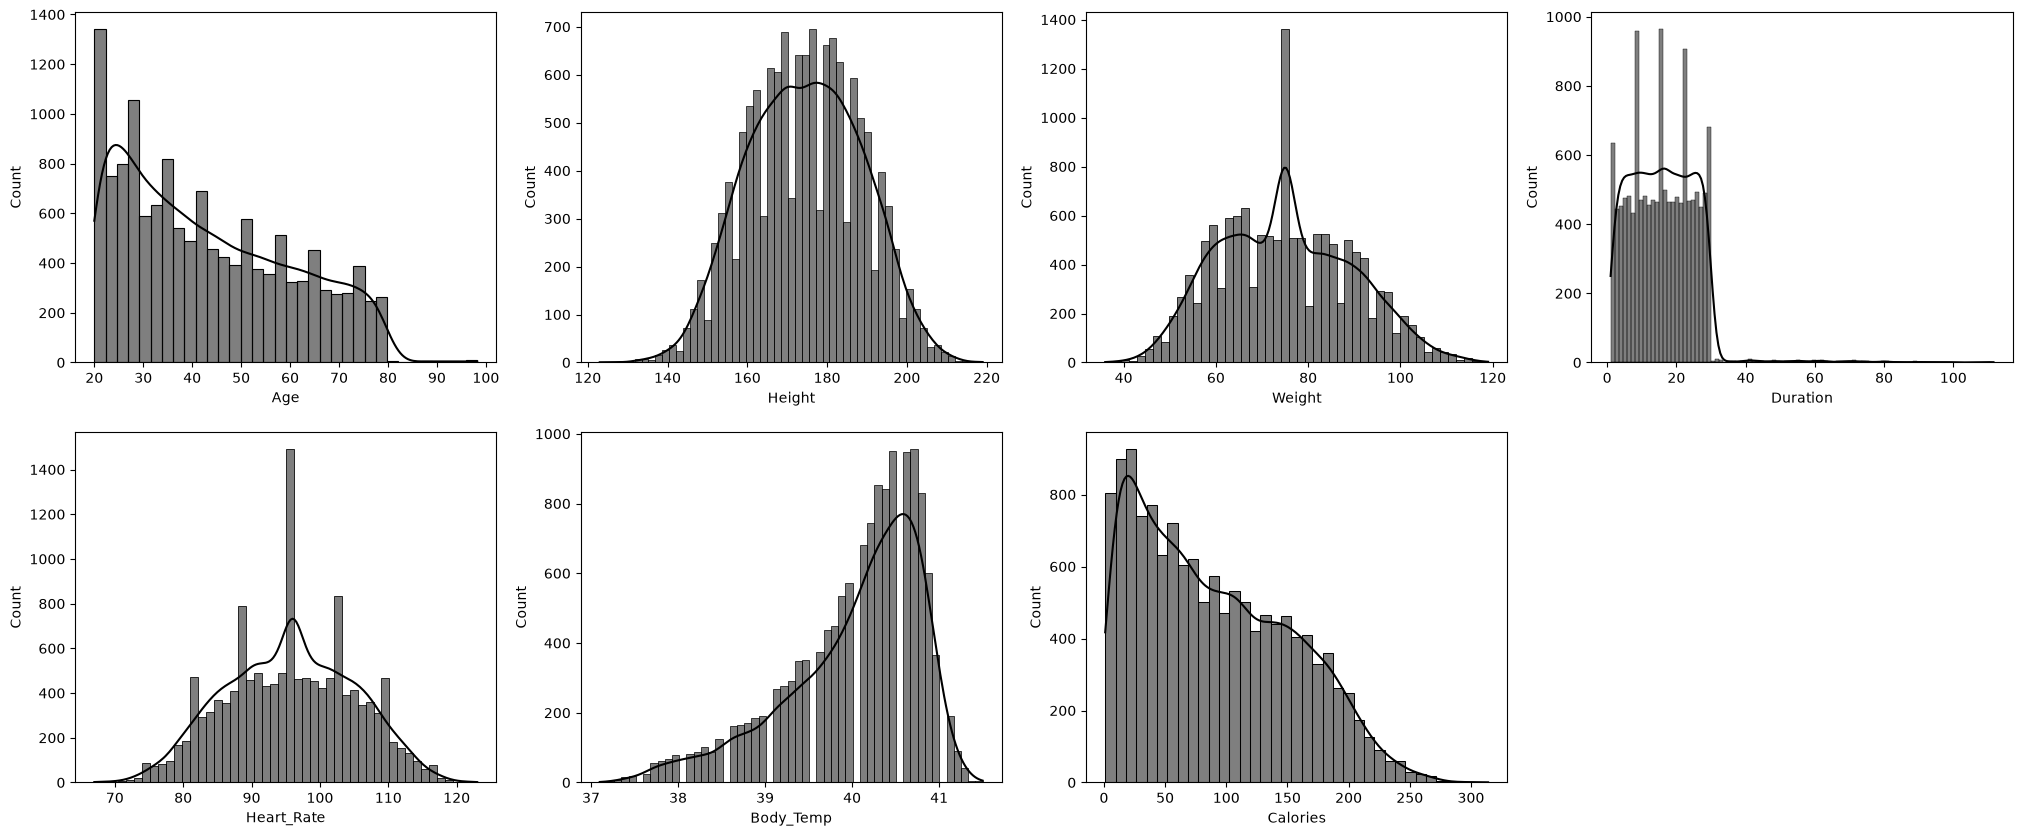

In [422]:
plt.figure (figsize= (25, 10))
for i, col in enumerate (num_cols, start= 1):
    plt.subplot (2, 4, i)
    sns.histplot (data= df, x= col, kde= True, color= "black")

plt.show ()

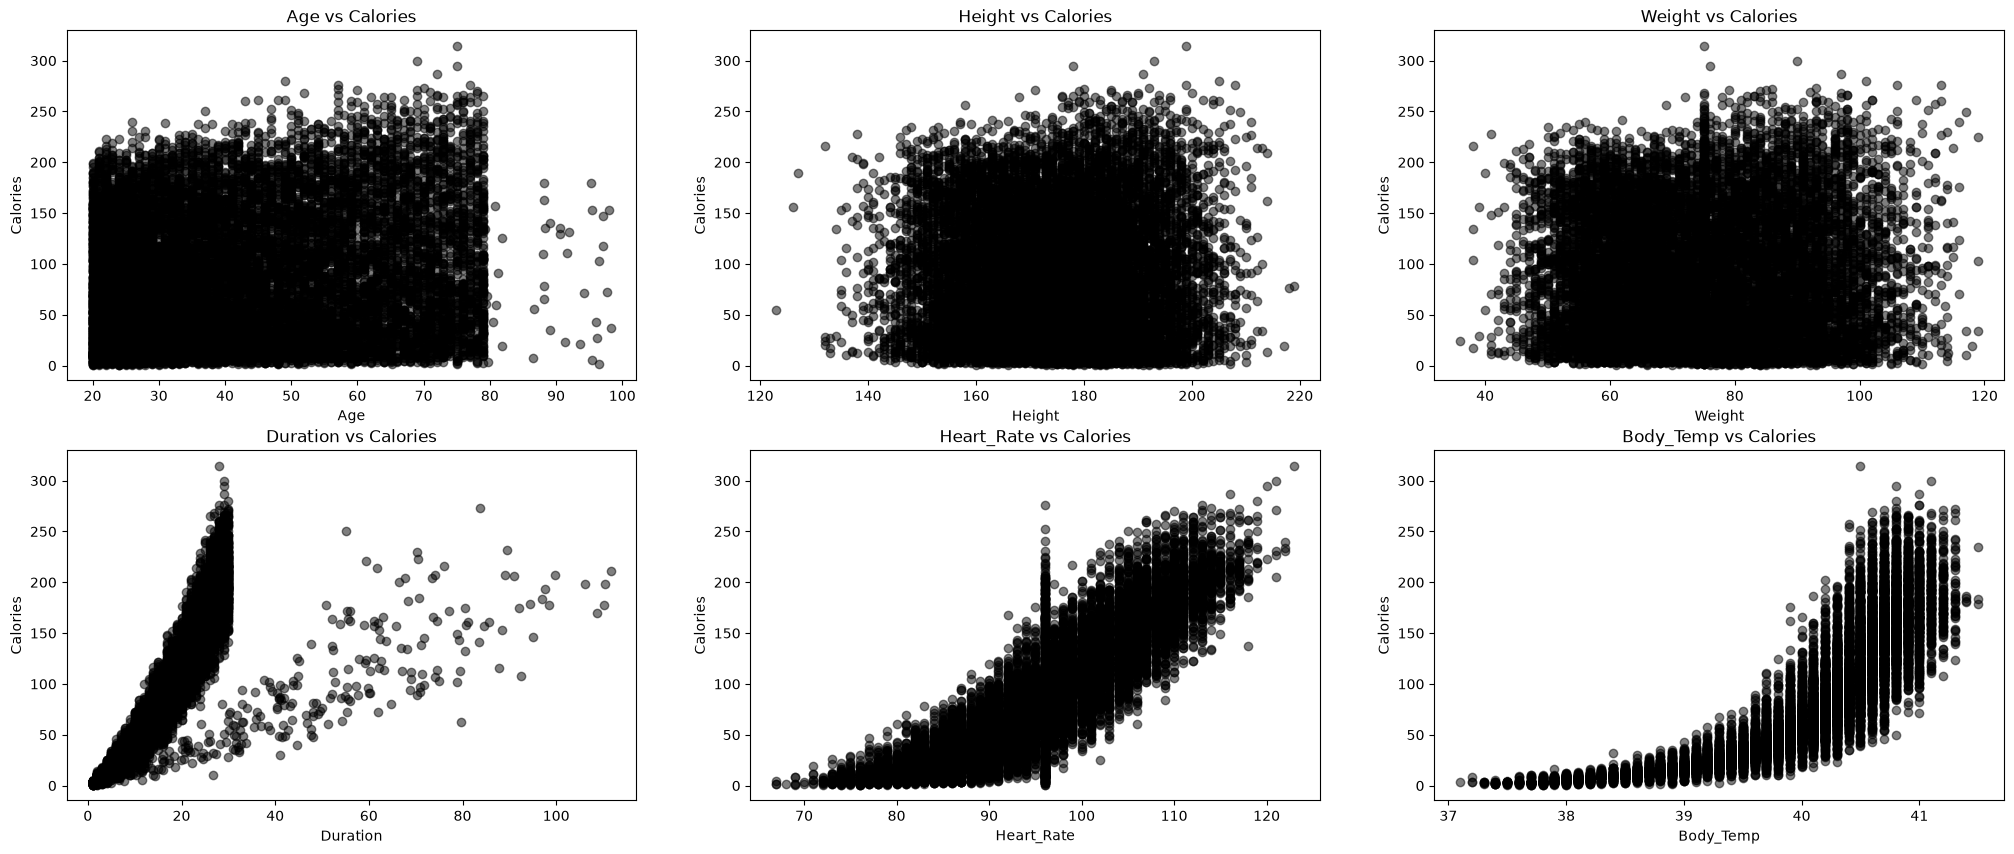

In [423]:
plt.figure (figsize= (25, 10))

if 'Calories' in num_cols:
    num_cols.remove ('Calories')

for i, col in enumerate (num_cols , start= 1):
    plt.subplot (2, 3, i)
    plt.scatter (df [col], df ["Calories"], color= "black", alpha= 0.5)
    plt.title (f"{col} vs Calories")
    plt.xlabel (col)
    plt.ylabel ("Calories")

plt.show ()

if 'Calories' not in num_cols:
    num_cols.append ('Calories')

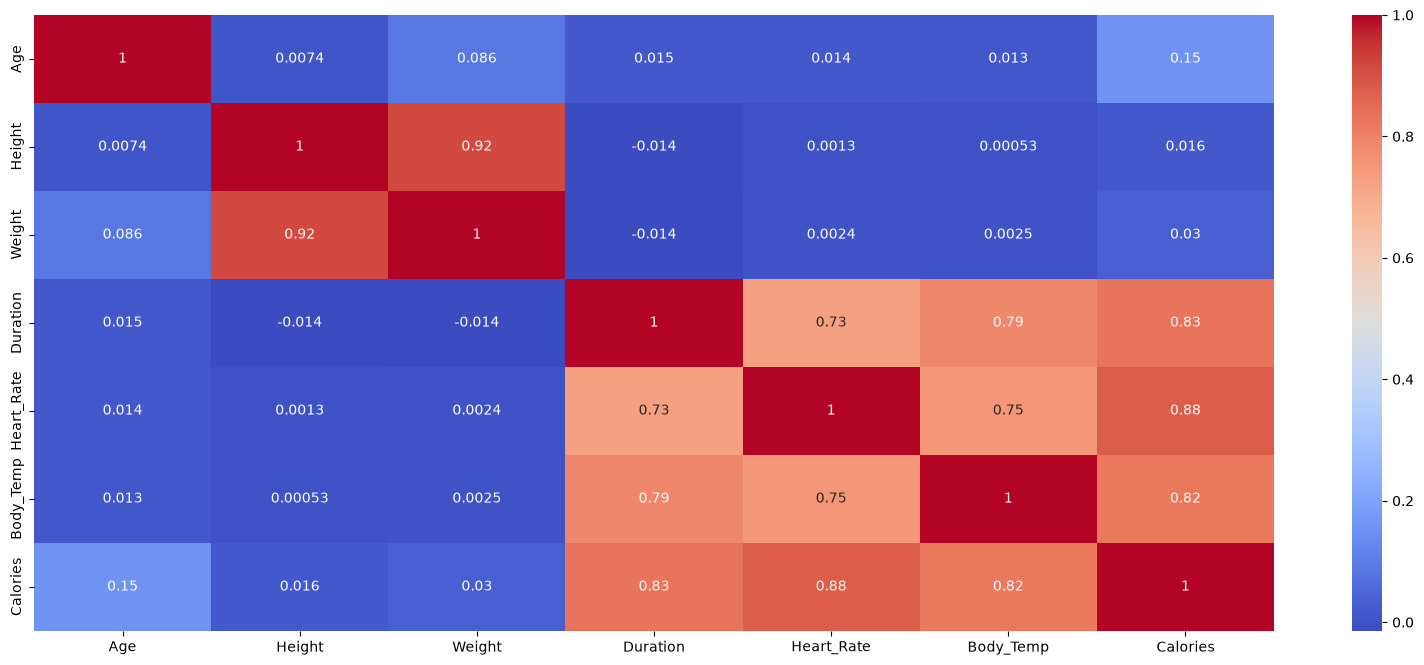

In [424]:
plt.figure (figsize= (20, 8))

corr = df.corr (numeric_only= True)
sns.heatmap (corr, annot= True, cmap= "coolwarm")
plt.show ()

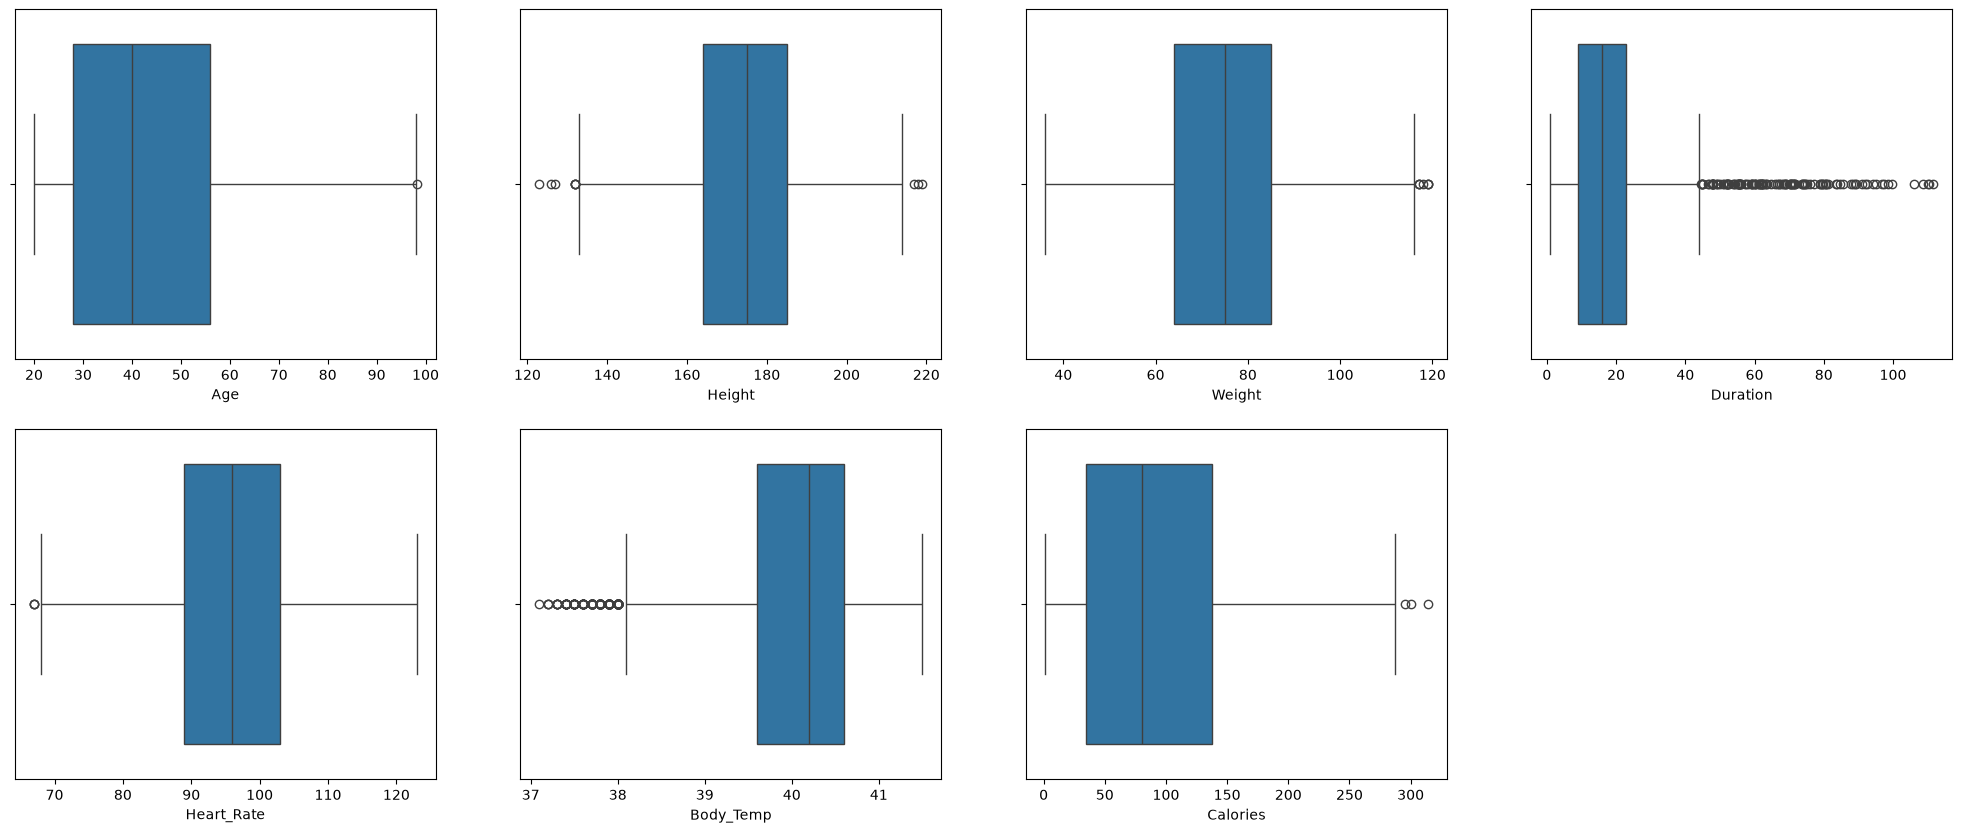

In [425]:
plt.figure (figsize= (25, 10))

for i, col in enumerate (num_cols, start= 1):
    plt.subplot (2, 4, i)
    sns.boxplot (data= df, x= col)

plt.show ()

### Categorical features

In [426]:
gender_counts = df ['Gender'].value_counts ()
gender_counts

Gender
female    7273
male      6420
Name: count, dtype: int64

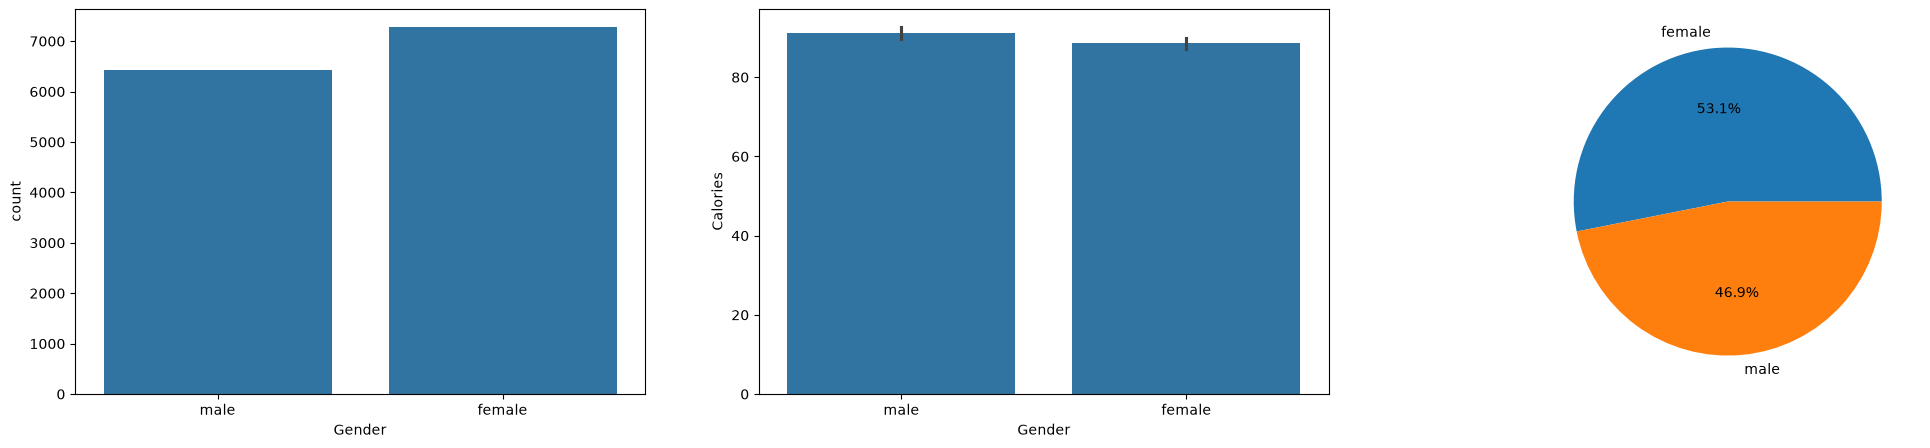

In [427]:
plt.figure (figsize= (25, 5))

plt.subplot (1, 3, 1)
sns.countplot (data= df, x= 'Gender')

plt.subplot (1, 3, 2)
sns.barplot (data= df, x= 'Gender', y= 'Calories')

plt.subplot (1, 3, 3)
plt.pie (gender_counts, labels= gender_counts.index, autopct= '%1.1f%%')

plt.show ()

## 9. Feature Engineering and selection

### BMI
`Create BMI from Height and Weight, then remove Height and Weight because they are highly correlated with each other and have very weak linear correlation with the target.`

In [428]:
df ["BMI"] = df ["Weight"] / (df["Height"] / 100) ** 2
df ["BMI"].describe ()

count   13,693.00
mean        24.43
std          1.97
min         15.64
25%         23.18
50%         24.39
75%         25.56
max         64.50
Name: BMI, dtype: float64

In [429]:
df = df.drop (columns= ["Height", "Weight"])
df.columns

Index(['Gender', 'Age', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories',
       'BMI'],
      dtype='object')

In [430]:
task = {
    'action' : 'Create BMI Column',
    'columns' : 'Heigh and Weight'
}

append_to_to_do (task)

task = {
    'action' : 'Remove Height and Weight Columns',
    'columns' : 'Height and Weight' 
}

append_to_to_do (task)
to_do

[{'action': 'Drop useless columns', 'columns': 'User_ID'},
 {'action': 'drop duplicates', 'columns': 'all'},
 {'action': 'Fill with mode', 'columns': 'Gender'},
 {'action': 'fill with median', 'columns': '[Weight, Heart_Rate]'},
 {'action': 'Remove the ages that greater than 100', 'columns': 'Age'},
 {'action': 'Remove the Height that greater than 219', 'columns': 'Height'},
 {'action': 'Remove the Weight that greater than 119', 'columns': 'Weight'},
 {'action': 'remove the Heart_Rate that greater than 124',
  'columns': 'Heart_Rate'},
 {'action': 'remove the Body_Temp that greater than 43',
  'columns': 'Body_Temp'},
 {'action': 'Create BMI Column', 'columns': 'Heigh and Weight'},
 {'action': 'Remove Height and Weight Columns',
  'columns': 'Height and Weight'}]

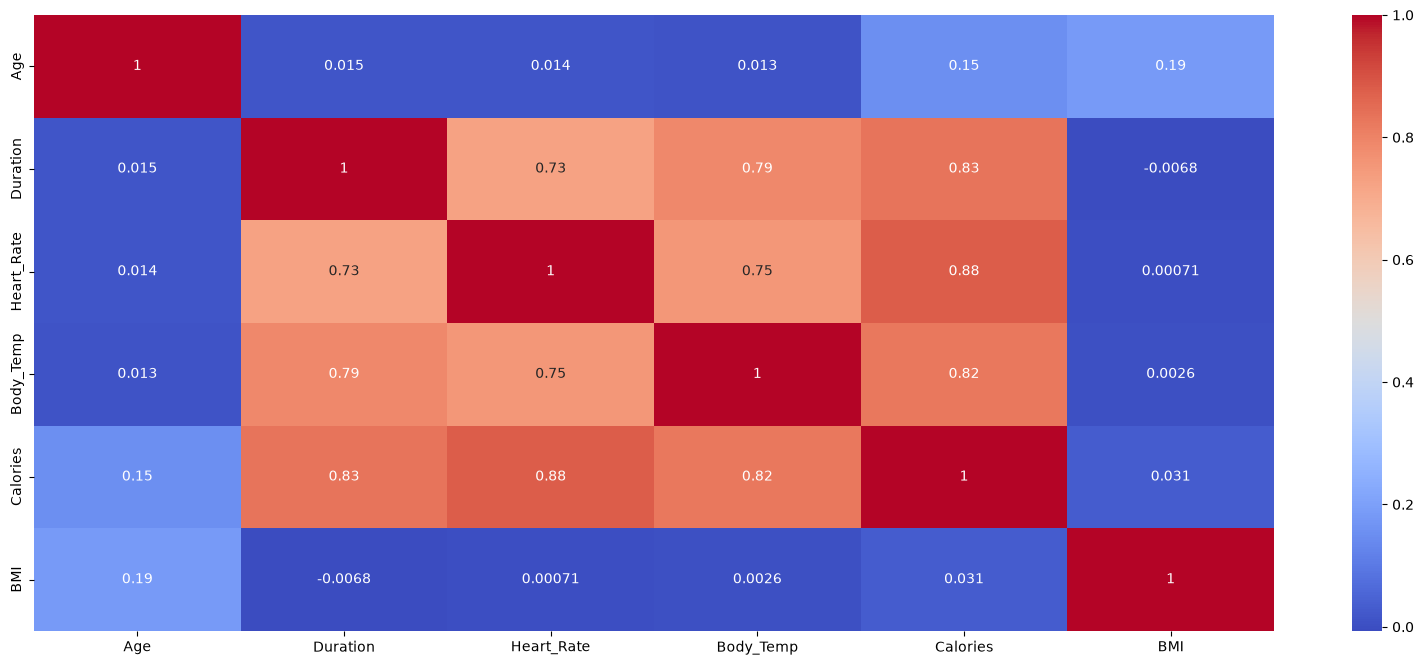

In [431]:
plt.figure (figsize= (20, 8))

corr = df.corr (numeric_only= True)
sns.heatmap (corr, annot= True, cmap= "coolwarm")
plt.show ()

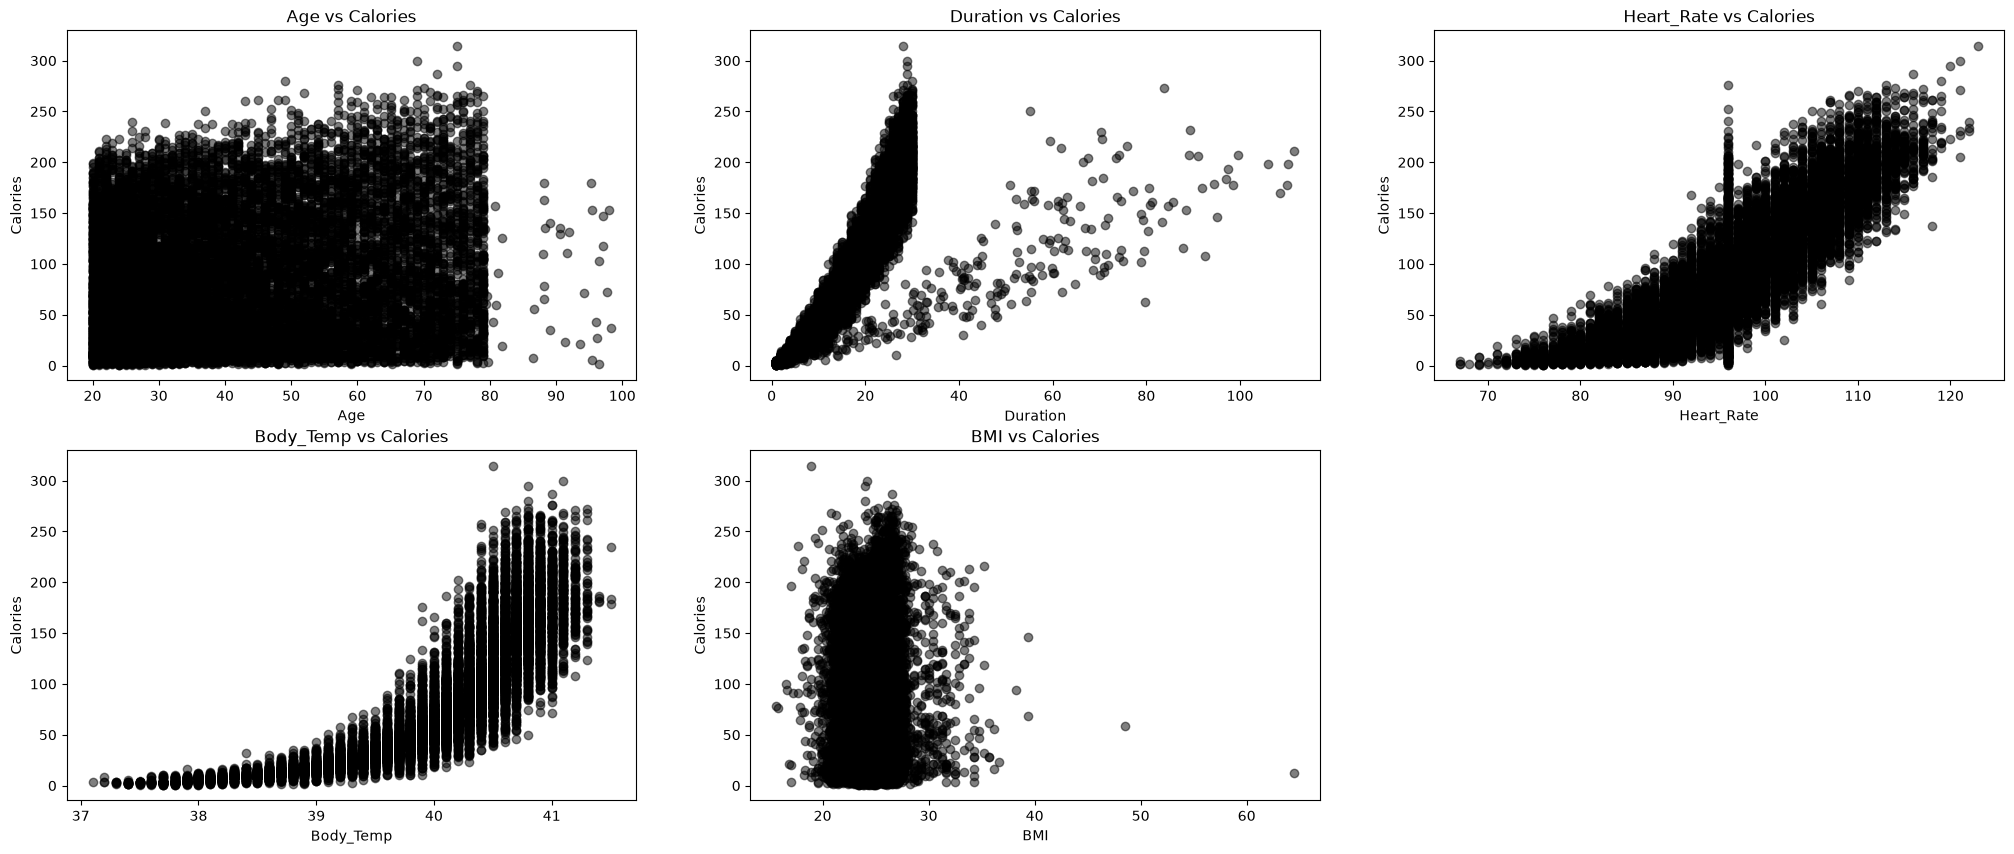

In [432]:
num_cols = ['Age', 'Duration', 'Heart_Rate', 'Body_Temp', 'BMI']

plt.figure (figsize= (25, 10))


for i, col in enumerate (num_cols , start= 1):
    plt.subplot (2, 3, i)
    plt.scatter (df [col], df ["Calories"], color= "black", alpha= 0.5)
    plt.title (f"{col} vs Calories")
    plt.xlabel (col)
    plt.ylabel ("Calories")

plt.show ()

In [433]:
df.groupby ("Gender")["Calories"].mean ().sort_values (ascending= False)

Gender
male     91.09
female   88.60
Name: Calories, dtype: float64

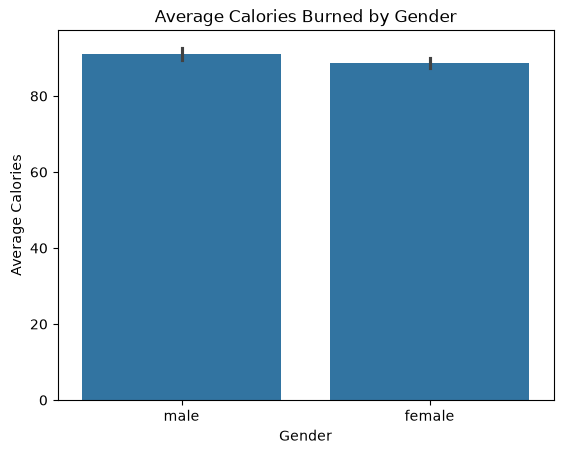

In [434]:
sns.barplot(
    data= df,
    x= "Gender",
    y= "Calories",
    estimator= "mean"
)

plt.title ("Average Calories Burned by Gender")
plt.xlabel ("Gender")
plt.ylabel ("Average Calories")
plt.show ()

## 10. Train / Test Split

In [435]:
df = pd.read_excel ('../data/calories_Dataset.xlsx')
df.shape

(15000, 9)

In [436]:
to_do

[{'action': 'Drop useless columns', 'columns': 'User_ID'},
 {'action': 'drop duplicates', 'columns': 'all'},
 {'action': 'Fill with mode', 'columns': 'Gender'},
 {'action': 'fill with median', 'columns': '[Weight, Heart_Rate]'},
 {'action': 'Remove the ages that greater than 100', 'columns': 'Age'},
 {'action': 'Remove the Height that greater than 219', 'columns': 'Height'},
 {'action': 'Remove the Weight that greater than 119', 'columns': 'Weight'},
 {'action': 'remove the Heart_Rate that greater than 124',
  'columns': 'Heart_Rate'},
 {'action': 'remove the Body_Temp that greater than 43',
  'columns': 'Body_Temp'},
 {'action': 'Create BMI Column', 'columns': 'Heigh and Weight'},
 {'action': 'Remove Height and Weight Columns',
  'columns': 'Height and Weight'}]

### Before splitting

| steps |
|--|
| Drop useless columns → User_ID|
| Drop duplicates|
| Remove invalid Age > 100|
| Remove invalid Height > 219|
| Remove invalid Weight > 119|
| Remove invalid Heart_Rate > 220|
| Remove invalid Body_Temp > 43|

In [437]:
# Drop useless columns
df = df.drop(columns=["User_ID"])

# Drop duplicates
df = df.drop_duplicates()

# Remove invalid Age
df = df[df["Age"].isna() | (df["Age"] <= AGE_MAX)]

# Remove invalid Height
df = df[df["Height"].isna() | (df["Height"] <= HEIGHT_MAX)]

# Remove invalid Weight
df = df[df["Weight"].isna() | (df["Weight"] <= WEIGHT_MAX)]

# Remove invalid Heart_Rate
df = df[df["Heart_Rate"].isna() | (df["Heart_Rate"] <= HEART_RATE_MAX)]

# Remove invalid Body_Temp
df = df[df["Body_Temp"].isna() | (df["Body_Temp"] <= BODY_TEMP_MAX)]

### Train / Test Split

In [438]:

X = df.drop (columns= ["Calories"])
y = df ["Calories"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### After splitting

| Steps |
| --- |
|Handle Missing Values: Gender fill with mode |
|Handle Missing Values: Weight & Heart_Rate fill with median |
| Feature Engineering → Create BMI|
| Feature Selection → Drop Height & Weight|
| Encoding|

In [439]:
# Numeric columns
numeric_cols = ["Weight", "Heart_Rate"]

# Categorical columns
categorical_cols = ["Gender"]

In [440]:
# Numeric features
numeric_imputer = SimpleImputer (strategy="median")

# Categorical feature
categorical_imputer = SimpleImputer(strategy="most_frequent")

X_train[["Weight", "Heart_Rate"]] = numeric_imputer.fit_transform(
    X_train[["Weight", "Heart_Rate"]]
)

X_test[["Weight", "Heart_Rate"]] = numeric_imputer.transform(
    X_test[["Weight", "Heart_Rate"]]
)

X_train[["Gender"]] = categorical_imputer.fit_transform(
    X_train[["Gender"]]
)

X_test[["Gender"]] = categorical_imputer.transform(
    X_test[["Gender"]]
)

In [441]:
X_train["BMI"] = X_train["Weight"] / (X_train["Height"] / 100) ** 2
X_test["BMI"] = X_test["Weight"] / (X_test["Height"] / 100) ** 2

In [442]:
X_train = X_train.drop(columns=["Height", "Weight"])
X_test = X_test.drop(columns=["Height", "Weight"])

In [443]:
X_train.columns

Index(['Gender', 'Age', 'Duration', 'Heart_Rate', 'Body_Temp', 'BMI'], dtype='object')

In [444]:
encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

X_train_gender = encoder.fit_transform(X_train[["Gender"]])
X_test_gender = encoder.transform(X_test[["Gender"]])

In [445]:
gender_columns = encoder.get_feature_names_out(["Gender"])

X_train_gender = pd.DataFrame(
    X_train_gender,
    columns=gender_columns,
    index=X_train.index
)

X_test_gender = pd.DataFrame(
    X_test_gender,
    columns=gender_columns,
    index=X_test.index
)

X_train = pd.concat(
    [X_train.drop(columns=["Gender"]), X_train_gender],
    axis=1
)

X_test = pd.concat(
    [X_test.drop(columns=["Gender"]), X_test_gender],
    axis=1
)

In [446]:
X_train.head ()

,Age,Duration,Heart_Rate,Body_Temp,BMI,Gender_male
3903,76.00,3.00,74.00,38.10,25.26,0.00
13951,39.00,18.00,89.00,40.30,19.66,1.00
14153,32.00,10.00,95.00,39.70,26.31,1.00
283,50.00,18.00,99.00,40.50,23.53,0.00
478,61.00,17.00,95.00,40.50,22.72,0.00


### Create scaling df copy

In [447]:
X_train_unscaled = X_train.copy ()
X_test_unscaled = X_test.copy ()

In [448]:
X_train_scaled = X_train_unscaled.copy ()
X_test_scaled = X_test_unscaled.copy ()

In [ ]:
numeric_cols = [
    "Age",
    "Duration",
    "Heart_Rate",
    "Body_Temp",
    "BMI"
]

# scaler = MinMaxScaler ()
scaler = StandardScaler ()

X_train_scaled[numeric_cols] = scaler.fit_transform(
    X_train_scaled[numeric_cols]
)

X_test_scaled[numeric_cols] = scaler.transform(
    X_test_scaled[numeric_cols]
)

In [450]:
X_train_scaled.head ()

,Age,Duration,Heart_Rate,Body_Temp,BMI,Gender_male
3903,1.93,-1.35,-2.32,-2.51,0.44,0.00
13951,-0.24,0.18,-0.71,0.34,-2.43,1.00
14153,-0.64,-0.63,-0.07,-0.44,0.98,1.00
283,0.41,0.18,0.36,0.60,-0.45,0.00
478,1.05,0.08,-0.07,0.60,-0.86,0.00


## 11. Models 🤖

### Scaled models

In [451]:
scaled_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Elastic Net": ElasticNet(),
    "SVR (Linear)": SVR(kernel="linear"),
    "SVR (RBF)": SVR(kernel="rbf"),
    "KNN Regressor": KNeighborsRegressor()
}


scaled_results = []

for name, model in scaled_models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    scaled_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })


scaled_results = pd.DataFrame(scaled_results)

scaled_results.sort_values("R²", ascending=False)

,Model,MAE,RMSE,R²
6,KNN Regressor,5.68,9.27,0.98
5,SVR (RBF),5.49,12.66,0.96
1,Ridge,15.96,21.70,0.88
0,Linear Regression,15.96,21.70,0.88
2,Lasso,16.01,21.75,0.88
3,Elastic Net,18.84,24.55,0.85
4,SVR (Linear),12.36,31.16,0.76


### Unscaled models

In [452]:
unscaled_models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    
    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        random_state=42
    )
}


unscaled_results = []

for name, model in unscaled_models.items():

    model.fit(X_train_unscaled, y_train)

    y_pred = model.predict(X_test_unscaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    unscaled_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })


unscaled_results = pd.DataFrame(unscaled_results)

unscaled_results.sort_values("R²", ascending=False)

,Model,MAE,RMSE,R²
4,Hist Gradient Boosting,3.49,6.42,0.99
2,Extra Trees,3.65,6.73,0.99
1,Random Forest,3.74,6.94,0.99
3,Gradient Boosting,4.47,7.51,0.99
0,Decision Tree,5.33,9.59,0.98


## 12. Evaluate Model

In [453]:
all_models_config = {
    # (model, X_train, X_test) - scaled models use X_train_scaled, tree-based use unscaled
    "Linear Regression": (LinearRegression(), X_train_scaled, X_test_scaled),
    "Ridge": (Ridge(), X_train_scaled, X_test_scaled),
    "Lasso": (Lasso(), X_train_scaled, X_test_scaled),
    "Elastic Net": (ElasticNet(), X_train_scaled, X_test_scaled),
    "SVR (Linear)": (SVR(kernel="linear"), X_train_scaled, X_test_scaled),
    "SVR (RBF)": (SVR(kernel="rbf"), X_train_scaled, X_test_scaled),
    "KNN Regressor": (KNeighborsRegressor(), X_train_scaled, X_test_scaled),
    "Decision Tree": (DecisionTreeRegressor(random_state=42), X_train_unscaled, X_test_unscaled),
    "Random Forest": (RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), X_train_unscaled, X_test_unscaled),
    "Extra Trees": (ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1), X_train_unscaled, X_test_unscaled),
    "Gradient Boosting": (GradientBoostingRegressor(random_state=42), X_train_unscaled, X_test_unscaled),
    "Hist Gradient Boosting": (HistGradientBoostingRegressor(random_state=42), X_train_unscaled, X_test_unscaled),
}

full_results = []

for name, (model, X_tr, X_te) in all_models_config.items():

    model.fit(X_tr, y_train)

    y_train_pred = model.predict(X_tr)
    y_test_pred = model.predict(X_te)

    # Train metrics
    mae_train = mean_absolute_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    r2_train = r2_score(y_train, y_train_pred)

    # Test metrics
    mae_test = mean_absolute_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2_test = r2_score(y_test, y_test_pred)

    full_results.append({
        "Model": name,
        "MAE (Train)": mae_train,
        "MAE (Test)": mae_test,
        "MAE (Diff)": mae_train - mae_test,
        "RMSE (Train)": rmse_train,
        "RMSE (Test)": rmse_test,
        "RMSE (Diff)": rmse_train - rmse_test,
        "R² (Train)": r2_train,
        "R² (Test)": r2_test,
        "R² (Diff)": r2_train - r2_test,
    })

full_results = pd.DataFrame(full_results)
full_results.sort_values("R² (Test)", ascending=False)

,Model,MAE (Train),MAE (Test),MAE (Diff),RMSE (Train),RMSE (Test),RMSE (Diff),R² (Train),R² (Test),R² (Diff)
11,Hist Gradient Boosting,3.02,3.49,-0.47,5.06,6.42,-1.35,0.99,0.99,0.00
9,Extra Trees,0.00,3.65,-3.65,0.00,6.73,-6.72,1.00,0.99,0.01
8,Random Forest,1.41,3.74,-2.33,2.62,6.94,-4.32,1.00,0.99,0.01
10,Gradient Boosting,4.33,4.47,-0.15,6.91,7.51,-0.60,0.99,0.99,0.00
6,KNN Regressor,4.80,5.68,-0.89,7.63,9.27,-1.64,0.98,0.98,0.01
7,Decision Tree,0.00,5.33,-5.33,0.00,9.59,-9.59,1.00,0.98,0.02
5,SVR (RBF),5.48,5.49,-0.01,12.09,12.66,-0.57,0.96,0.96,0.00
1,Ridge,15.66,15.96,-0.30,21.34,21.70,-0.36,0.88,0.88,0.00
0,Linear Regression,15.66,15.96,-0.30,21.34,21.70,-0.36,0.88,0.88,0.00
2,Lasso,15.73,16.01,-0.28,21.41,21.75,-0.34,0.88,0.88,0.00


### Overfitting Models

| Model         |
| ------------- |
| Extra Trees   |
| Random Forest |
| Decision Tree |

### Selected Model

**HistGradientBoostingRegressor**

| Metric | Train | Test | Difference |
| ------ | ----: | ---: | ---------: |
| MAE    |  3.02 | 3.49 |      -0.47 |
| RMSE   |  5.06 | 6.42 |      -1.35 |
| R²     |  0.99 | 0.99 |       0.00 |

The model achieved:

* **Test MAE:** 3.49
* **Test RMSE:** 6.42
* **Test R²:** 0.99
* **R² Gap:** 0.00


### Final model

In [454]:
model = HistGradientBoostingRegressor(
    random_state=42
)

model.fit (X_train_unscaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255


## 13. Optimization

In [460]:
param_grid = {
    "learning_rate": [0.05, 0.1, 0.2],
    "max_iter": [100, 200, 300],
    "max_leaf_nodes": [31, 63],
    "min_samples_leaf": [20, 30],
}

search = GridSearchCV(
    estimator=HistGradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
)

search.fit(X_train_unscaled, y_train)

print("Best params:", search.best_params_)
print("Best CV R²:", search.best_score_)

best_model = search.best_estimator_
y_pred = best_model.predict(X_test_unscaled)

print("Tuned Test MAE :", mean_absolute_error(y_test, y_pred))
print("Tuned Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Tuned Test R²  :", r2_score(y_test, y_pred))

Best params: {'learning_rate': 0.05, 'max_iter': 300, 'max_leaf_nodes': 31, 'min_samples_leaf': 20}
Best CV R²: 0.9903851909380343
Tuned Test MAE : 3.3716873761289277
Tuned Test RMSE: 6.248224794931897
Tuned Test R²  : 0.990224224825991


## 14. Save the model

In [455]:
joblib.dump (model, "model.joblib")

['model.joblib']

In [461]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.ensemble import HistGradientBoostingRegressor

model = HistGradientBoostingRegressor(
    random_state=42
)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    model,
    X_train_unscaled,
    y_train,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }
)

print("MAE:", -scores["test_MAE"])
print("RMSE:", -scores["test_RMSE"])
print("R²:", scores["test_R2"])

MAE: [3.67071076 3.67449468 3.34376052 3.39605643 3.69672379]
RMSE: [6.46839    6.53251007 5.72198245 5.91775706 6.77311923]
R²: [0.98908767 0.98897684 0.99139535 0.99106789 0.98832654]
